# Plan bruit de la Métropole de Lyon — road noise 2022

Downloads the strategic road-traffic noise map 2022 of the Métropole de Lyon
(produced with Acoucité, published on [data.grandlyon.com](https://data.grandlyon.com/jeux-de-donnees/plan-bruit-metropole-lyon/info),
Licence Ouverte). Unlike the other cities, the noise data is published as **continuous
modeled dB rasters** (GeoTIFF, 10 m resolution, EPSG:2154 Lambert-93):

- `GL_Rte_Lden.tif` — Lden, the 24 h day-evening-night composite indicator
- `GL_Rte_Ln.tif` — Ln, the night period (22–6 h)

Lyon publishes no separate day/evening rasters, so downstream `db_day` and `db_evening`
both take the Lden value (Milan precedent), and `db_night` takes Ln. Note that Lden
slightly overstates the plain daytime level (evening is up-weighted +5 dB, night +10 dB).
The rasters cover road-traffic noise only (rail/air/industry are separate datasets).

# Task 1 — download the rasters

In [1]:
import os
import io
import time
import zipfile
import requests
import numpy as np
import rasterio
import matplotlib.pyplot as plt

In [2]:
_layers_dir = os.path.join(os.path.dirname(os.path.abspath(os.getcwd())), 'layers')
os.makedirs(_layers_dir, exist_ok=True)

RASTERS = {
    'GL_Rte_Lden.tif': 'https://download.data.grandlyon.com/files/grandlyon/imagerie/noi2022/ROUTE2022/GL_Rte_Lden.zip',
    'GL_Rte_Ln.tif': 'https://download.data.grandlyon.com/files/grandlyon/imagerie/noi2022/ROUTE2022/GL_Rte_Ln.zip',
}

for tif_name, url in RASTERS.items():
    tif_path = os.path.join(_layers_dir, tif_name)
    if os.path.exists(tif_path):
        print('Already present, skipping download:', tif_name)
        continue
    for attempt in range(3):
        try:
            print('Downloading', url)
            r = requests.get(url, timeout=300)
            r.raise_for_status()
            with zipfile.ZipFile(io.BytesIO(r.content)) as z:
                z.extract(tif_name, _layers_dir)
            print('Extracted', tif_name)
            break
        except Exception as e:
            print(f'Attempt {attempt + 1} failed: {e}')
            if attempt == 2:
                raise
            time.sleep(5)

Extracted GL_Rte_Lden.tif


Extracted GL_Rte_Ln.tif


# Task 2 — inspect the rasters

In [3]:
lden_src = rasterio.open(os.path.join(_layers_dir, 'GL_Rte_Lden.tif'))
ln_src = rasterio.open(os.path.join(_layers_dir, 'GL_Rte_Ln.tif'))

for name, src in [('Lden', lden_src), ('Ln', ln_src)]:
    print(f'{name}: CRS={src.crs}  size={src.width}x{src.height}  res={src.res}')
    print(f'      bounds={tuple(round(b) for b in src.bounds)}  nodata={src.nodata}')

Lden: CRS=EPSG:2154  size=3601x4401  res=(10.0, 10.0)
      bounds=(827995, 6495995, 864005, 6540005)  nodata=-9999.0


Ln: CRS=EPSG:2154  size=3601x4401  res=(10.0, 10.0)
      bounds=(827995, 6495995, 864005, 6540005)  nodata=-9999.0


In [4]:
# dB statistics over the valid (non-nodata) pixels
lden = lden_src.read(1)
ln = ln_src.read(1)
lden_valid = lden[lden != lden_src.nodata]
ln_valid = ln[ln != ln_src.nodata]

for name, vals in [('Lden', lden_valid), ('Ln', ln_valid)]:
    print(f'{name}: min={vals.min():.1f}  mean={vals.mean():.1f}  max={vals.max():.1f}  '
          f'valid pixels={len(vals):,}')

Lden: min=6.4  mean=55.0  max=98.6  valid pixels=5,374,547
Ln: min=-4.1  mean=44.6  max=88.2  valid pixels=5,374,547


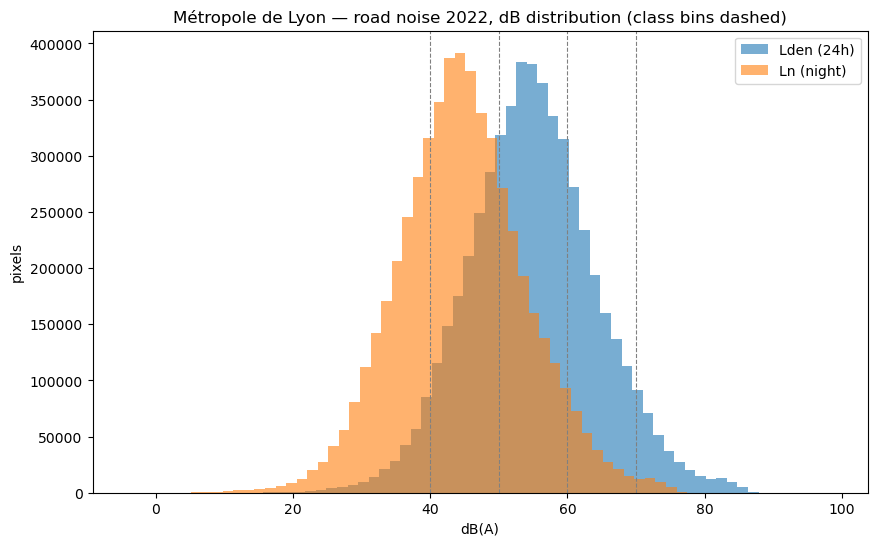

In [5]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(lden_valid, bins=60, alpha=0.6, label='Lden (24h)')
ax.hist(ln_valid, bins=60, alpha=0.6, label='Ln (night)')
ax.axvline(40, color='gray', ls='--', lw=0.8)
ax.axvline(50, color='gray', ls='--', lw=0.8)
ax.axvline(60, color='gray', ls='--', lw=0.8)
ax.axvline(70, color='gray', ls='--', lw=0.8)
ax.set_xlabel('dB(A)')
ax.set_ylabel('pixels')
ax.set_title('Métropole de Lyon — road noise 2022, dB distribution (class bins dashed)')
ax.legend()
plt.show()

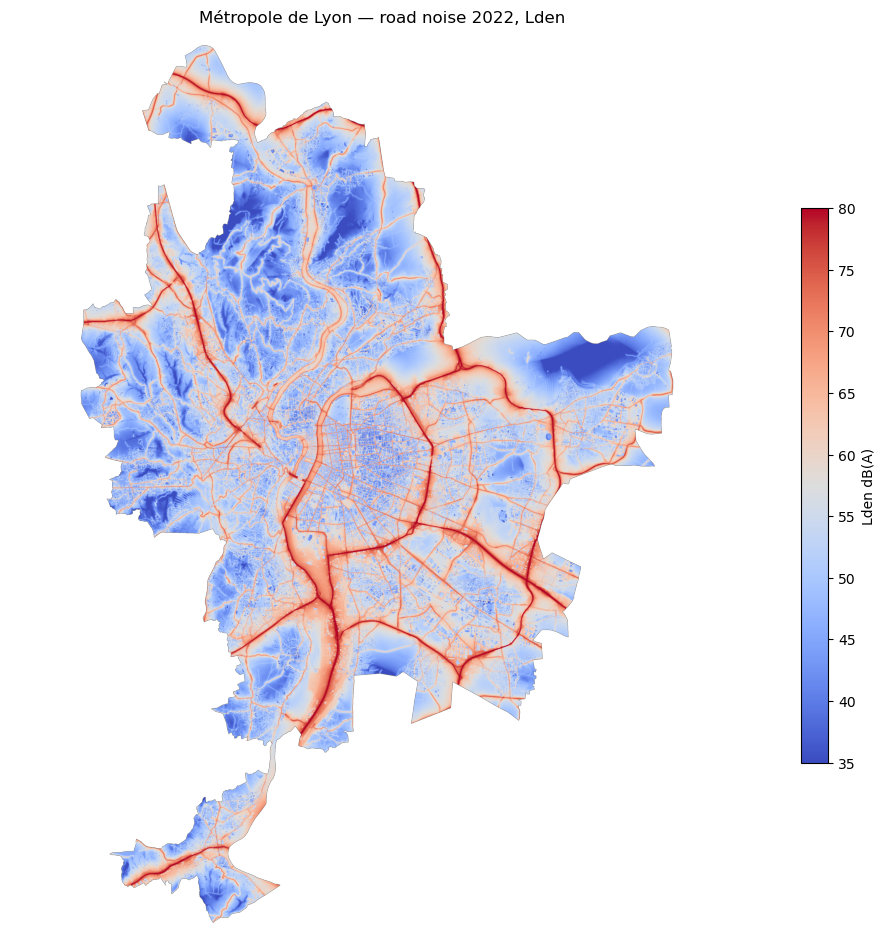

In [6]:
arr = np.ma.masked_equal(lden, lden_src.nodata)
fig, ax = plt.subplots(figsize=(12, 12))
im = ax.imshow(arr, cmap='coolwarm', vmin=35, vmax=80)
plt.colorbar(im, ax=ax, shrink=0.6, label='Lden dB(A)')
ax.set_title('Métropole de Lyon — road noise 2022, Lden')
ax.set_axis_off()
plt.show()

The rasters stay in `../layers/` and are sampled at the OSM street midpoints in
`LYO_OSM_roads_noise_class.ipynb`.